In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [7]:
velocidades_conjuntas = r"C:\Users\Jessi Dani\OneDrive - Universidad de los andes\TESIS\Tesis\Datos ESPARTACO\Visualizacion_velocidades\recopliacion_velocidades.xlsx"

velocidades = pd.read_excel(velocidades_conjuntas, skiprows = 3, usecols=[2, 3, 4, 5], header=None, names =["Fecha", "VR Absorción Hα [km/s]", "VR Emisión Hα [km/s]", "VR Co I [km/s]"])

velocidades["Fecha"] = pd.to_datetime(velocidades["Fecha"], format="%d/%m/%Y")

In [10]:
#velocidades

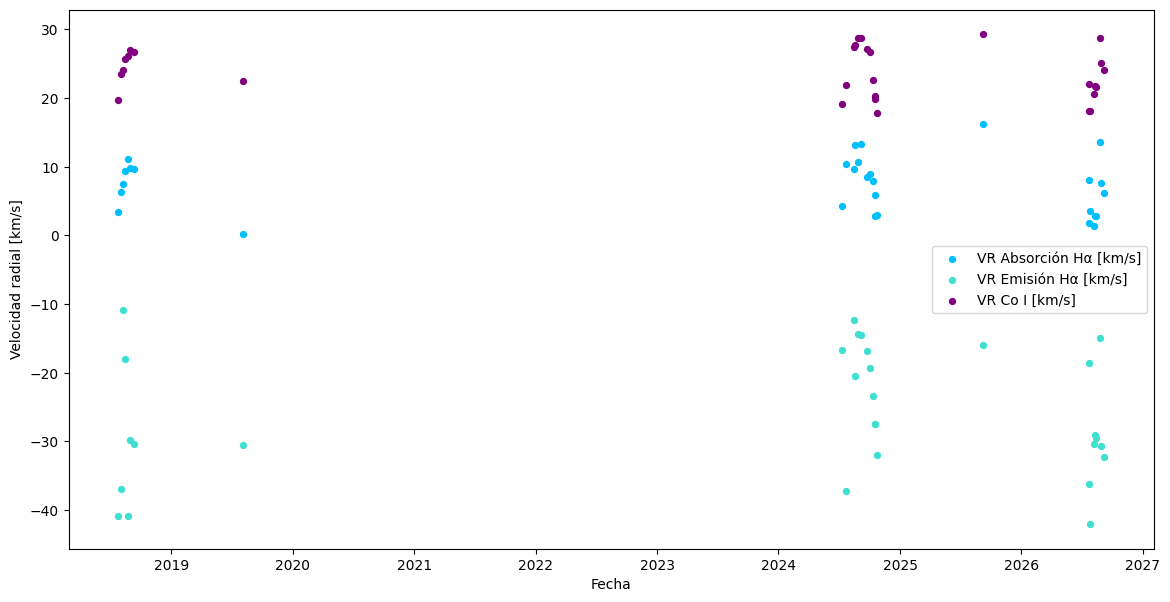

In [18]:
fecha, absorcion_h, emision_h, absorcion_coi =velocidades["Fecha"], velocidades["VR Absorción Hα [km/s]"], velocidades["VR Emisión Hα [km/s]"], velocidades["VR Co I [km/s]"]

plt.figure(figsize=(14, 7))

plt.scatter(fecha, absorcion_h, s=18, color="deepskyblue", label="VR Absorción Hα [km/s]", zorder=3)
plt.scatter(fecha, emision_h, s=18, color="turquoise", label="VR Emisión Hα [km/s]", zorder=3)
plt.scatter(fecha, absorcion_coi, s=18, color="purple", label="VR Co I [km/s]", zorder=3)

plt.xlabel("Fecha")
plt.ylabel("Velocidad radial [km/s]")
plt.legend()
plt.show()


In [30]:
# Columnas
series = [
    ("VR Absorción Hα [km/s]", "deepskyblue", "o", "Absorción Hα"),
    ("VR Emisión Hα [km/s]",   "turquoise",   "o", "Emisión Hα"),
    ("VR Co I [km/s]",         "purple",      "o", "[Co I]"),
]

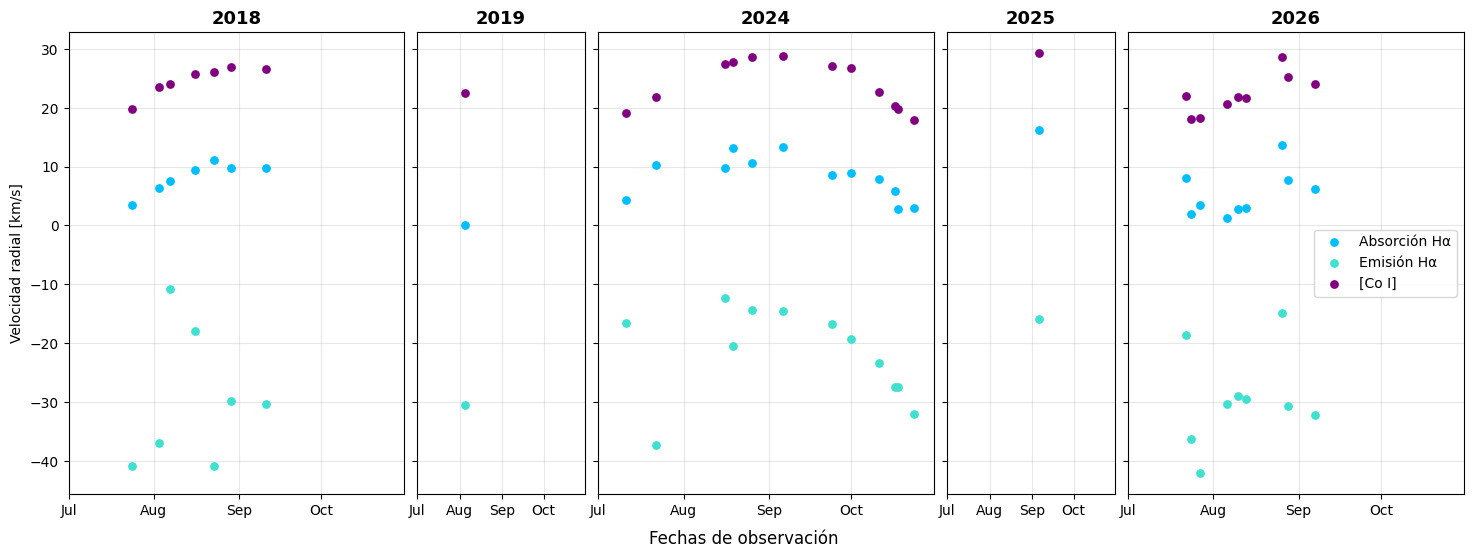

In [33]:
años_panel = [2018, 2019, 2024, 2025, 2026]

fig, axes = plt.subplots(
    1, len(años_panel), figsize=(18, 6), sharey=True,
    gridspec_kw={"wspace": 0.05, "width_ratios": [1, 0.5, 1, 0.5, 1]}
)

for ax, año in zip(axes, años_panel):
    datos = velocidades[velocidades["Fecha"].dt.year == año]

    for col, color, marcador, etiqueta in series:
        ax.scatter(datos["Fecha"], datos[col], s=28, color=color,
                   marker=marcador, label=etiqueta, zorder=3)

    ax.set_xlim(pd.Timestamp(f"{año}-07-01"), pd.Timestamp(f"{año}-10-31"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_title(str(año), fontsize=13, fontweight="bold")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Velocidad radial [km/s]")
axes[-1].legend(loc="center right", fontsize=10)
fig.supxlabel("Fechas de observación", y=0.02)

plt.savefig(r"Visualizacion_velocidades\VR_componentes_por_año.png", dpi=300, bbox_inches="tight")
plt.show()